# [Project] 글로벌 바이오 섹터의 정보 전이(Information Spillover) 분석
## : 미국 시장(NBI)과 금리 변동이 국내 바이오 수익률에 미치는 시차 효과 연구

### 1. 연구 배경 (Introduction)
* **바이오 산업의 특성**: 바이오 기업은 신약 파이프라인의 가치가 미래 현금 흐름에 의존하는 롱 듀레이션(Long Duration) 자산입니다. 따라서 금리 변화와 글로벌 센티먼트에 매우 민감하게 반응합니다.
* **가설**: 글로벌 바이오 벤치마크인 나스닥 바이오 지수(NBI)와 미 국채 금리의 변동은 한국 바이오 시장에 일정한 시차(Time-lag)를 두고 반영될 것이다.
* **목적**: 정성적인 시장 해석을 넘어, VAR(벡터 자기회귀) 모델과 회귀 분석을 통해 시장 간의 정보 전이 경로를 정량적으로 구조화합니다.

In [19]:
import FinanceDataReader as fdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# 1. 주가 데이터 수집
def fetch_price_data(ticker, start_date, end_date=None):
    """특정 종목의 종가(Close) 데이터를 가져옵니다."""
    return fdr.DataReader(ticker, start_date, end_date)['Close']

# 2. 수익률 계산 (일별 / 누적)
def calc_daily_return(price_data):
    """전일 대비 오늘 주가의 변동률(일별 수익률)을 계산합니다."""
    return (price_data / price_data.shift(1)).fillna(1)

def calc_cumulative_return(price_data):
    """투자 시작일 기준 현재까지의 누적 수익률(자산의 흐름)을 계산합니다."""
    return price_data / price_data.iloc[0]

# 3. 기본 포트폴리오 성과 (리밸런싱 없는 단순 보유)
def run_static_portfolio(price_data, weights=None):
    """한 번 정한 비중을 끝까지 유지할 때의 수익률을 계산합니다."""
    daily_ret = calc_daily_return(price_data)
    cum_ret = calc_cumulative_return(price_data)

    # 비중을 설정하지 않았다면 모든 자산에 동일하게 배분 (1/N 비율)
    if weights is None:
        num_assets = len(price_data.columns)
        weights = [1 / num_assets] * num_assets
        
    # 포트폴리오 전체의 누적 및 일별 수익률 계산
    port_cum_return = (weights * cum_ret).sum(axis=1)
    port_daily_return = (port_cum_return / port_cum_return.shift(1)).fillna(1)
    
    return port_daily_return, port_cum_return

# 4. 투자 성과 평가 지표 (CAGR, MDD)
def evaluate_performance(cum_returns):
    """연평균 성장률(CAGR)과 최대 낙폭(MDD)을 계산합니다."""
    cagr = cum_returns.iloc[-1] ** (252 / len(cum_returns))
    
    # 최대 낙폭(MDD): 역사적 고점 대비 얼마나 떨어졌는가 측정
    historical_max = cum_returns.cummax()
    drawdown = (historical_max - cum_returns) / historical_max * 100
    mdd = drawdown.max()
    
    print(f" 최종 수익률: {cum_returns.iloc[-1]:.4f}")
    print(f" CAGR (연평균 수익률): {cagr:.4f}")
    print(f" MDD (최대 낙폭): {mdd:.2f}%")

    return cagr, drawdown, mdd

# 5. 리밸런싱 날짜 추출기
def get_rebalance_points(price_data, freq="month"):
    """월, 분기, 연 단위로 자산 비중을 재조정(리밸런싱)할 날짜를 찾습니다."""
    # 주가 데이터의 인덱스(날짜)만 가져와서 연/월 컬럼 생성
    df_dates = pd.DataFrame(index=price_data.index)
    df_dates['year'] = df_dates.index.year
    df_dates['month'] = df_dates.index.month
    
    if freq == "month":
        # 매월 마지막 날짜 추출
        rebalance_dates = df_dates.drop_duplicates(['year', 'month'], keep="last").index
    elif freq == "quarter":
        # 3, 6, 9, 12월의 마지막 날짜 추출
        quarter_months = [3, 6, 9, 12]
        df_quarters = df_dates[df_dates['month'].isin(quarter_months)]
        rebalance_dates = df_quarters.drop_duplicates(['year', 'month'], keep="last").index
    elif freq == "year":
        # 매년 마지막 날짜 추출
        rebalance_dates = df_dates.drop_duplicates(['year'], keep="last").index
        
    return rebalance_dates

# 6. 리밸런싱 포트폴리오 백테스트 실행
def run_rebalance_backtest(price_data, freq="month", weight_df=None):
    """주기적으로 자산 비중을 재조정하는 투자의 성과를 시뮬레이션합니다."""
    assets_cols = price_data.columns
    
    # 투자 비중이 주어지지 않았다면 자동으로 동일 비중(1/N) 적용
    if weight_df is None:
        rebal_dates = get_rebalance_points(price_data, freq)
        equal_weight = [1 / len(assets_cols)] * len(assets_cols)
        weight_df = pd.DataFrame([equal_weight] * len(rebal_dates),
                                 index=rebal_dates, columns=assets_cols)
    else:
        # 비중 데이터가 주어졌다면, 첫 투자 시점에 맞춰 주가 데이터를 자름
        start_date = weight_df.index[0]
        price_data = price_data.loc[start_date:]
        rebal_dates = get_rebalance_points(price_data, freq)
        
    portfolio_history = []  # 매 구간의 결과를 담을 빈 리스트
    current_asset_value = 1.0  # 초기 자산 가치
    start = rebal_dates[0]

    # 두 번째 리밸런싱 날짜부터 루프 시작 (구간별 수익률 계산)
    for end in rebal_dates[1:]:
        current_weights = weight_df.loc[start]
        period_prices = price_data.loc[start:end]
        
        # 해당 기간 동안의 누적 수익률 계산
        period_cum_ret = calc_cumulative_return(period_prices)
        
        # 비중을 곱한 수익률에 이전까지의 총 자산 규모를 곱함
        weighted_ret = current_weights * period_cum_ret
        net_value_flow = current_asset_value * weighted_ret

        # 다음 구간을 위해 변수 업데이트 (start를 end로 갱신)
        start = end
        current_asset_value = net_value_flow.iloc[-1].sum()
        portfolio_history.append(net_value_flow)
    
    # 리스트에 모은 결과들을 하나의 데이터프레임으로 합침
    final_portfolio = pd.concat(portfolio_history)
    # 날짜가 겹치는 연결 부위 제거
    final_portfolio = final_portfolio.loc[~final_portfolio.index.duplicated(keep='last')]
    
    port_cum_ret = final_portfolio.sum(axis=1)
    port_daily_ret = (port_cum_ret / port_cum_ret.shift(1)).fillna(1)
    
    return port_daily_ret, port_cum_ret

### 2. 연구 데이터 수집 및 전처리 (Data Acquisition & Preprocessing)

본 연구에서는 글로벌 바이오 센티먼트의 전이 경로를 분석하기 위해, 거시경제 지표와 시장 지표를 결합한 다변량 시계열 데이터를 구축합니다. 

#### **(1) 분석 대상 및 선정 사유**
* **NBI (Nasdaq Biotechnology Index)**: 글로벌 바이오 산업의 표준 벤치마크로, 국내 바이오 투자 심리에 선행 지표 역할을 수행함.
* **KRX_Bio (TIGER 헬스케어, 227540)**: 국내 바이오 및 헬스케어 섹터를 대표하는 지수로, 본 연구의 주요 종속 변수(Target)임.
* **Yield (미 국채 10년물 금리, ^TNX)**: 바이오 기업은 미래 현금 흐름의비중이 큰 롱 듀레이션' 자산임. 따라서 무위험 수익률인 국채 금리는 밸류에이션 할인율을 결정하는 핵심 매크로 변수임.

#### **(2) 시계열 데이터 정제 전략 (Feature Engineering)**
바이오 실험에서 분석 전 시료를 보정(Calibration)하듯, 금융 데이터 또한 통계 모델에 적합하도록 다음과 같은 전처리를 수행합니다.

* **정상성(Stationarity) 확보**: 주가 데이터(Level)는 추세(Trend)로 인해 통계적 왜곡을 일으킬 수 있으므로, 이를 **일별 수익률(Percent Change)**로 변환하여 분석의 안정성을 확보함.
* **시계열 연속성 보정 (Time-series Continuity)**: 
    - 주식 시장의 휴장일(주말, 공휴일)로 인해 발생하는 데이터 공백을 해결하기 위해 **영업일 주기(Business Day, 'B')**를 명시적으로 설정함.
    - 미세한 결측치는 **전일 데이터 전이(Forward Fill)** 방식으로 보정하여, VAR 모델 적합 시 발생할 수 있는 시간적 불연속성(ValueWarning)을 사전에 방지함.
* **한-미 시차 동기화**: 미국 시장(NBI)의 종가가 한국 시장(KRX_Bio)의 당일 오전에 영향을 미칠 수 있도록 데이터 구조를 설계함.

In [20]:
start_date = '2022-01-01'
tickers = {'NBI': 'NBI', 'KRX_Bio': '227540', 'Yield': '^TNX'}
df_raw = pd.DataFrame()

for name, ticker in tickers.items():
    df_raw[name] = fetch_price_data(ticker, start_date)

# 1. 결측치 제거 및 영업일 주기('B') 설정
# 주말/공휴일 빈칸을 채워주어 시계열의 연속성을 확보합니다.
df_clean = df_raw.dropna().asfreq('B').ffill()

# 2. 수익률 변환
returns = df_clean.pct_change().dropna()

# 3. 인덱스에 명시적으로 주기 정보 주입 (Warning 방지)
returns.index.freq = 'B'

print("데이터 준비 완료")
print(returns.tail())

데이터 준비 완료
                 NBI   KRX_Bio     Yield
2026-03-24 -0.007279  0.029547  0.013383
2026-03-25  0.026380  0.031052 -0.014572
2026-03-26 -0.002246  0.005476  0.020333
2026-03-27 -0.029255  0.010211  0.005435
2026-03-30  0.006314 -0.028527 -0.022072


### 3. 통계적 유의성 검정
* **ADF Test**: 수익률 데이터가 통계적으로 안정적인지 확인합니다.
* **VAR Model**: 다변량 시계열 모델을 통해 최적의 정보 전이 시차(Lag)를 탐색합니다.
* **Granger Causality**: 미국 시장과 금리가 한국 시장에 미치는 선행성을 통계적으로 검정합니다.

ADF Test Results
NBI: p-value = 0.0000
KRX_Bio: p-value = 0.0000
Yield: p-value = 0.0000

최적 시차(AIC 기준): 1일
NBI -> KRX_Bio 인과관계 유의성: 0.0000


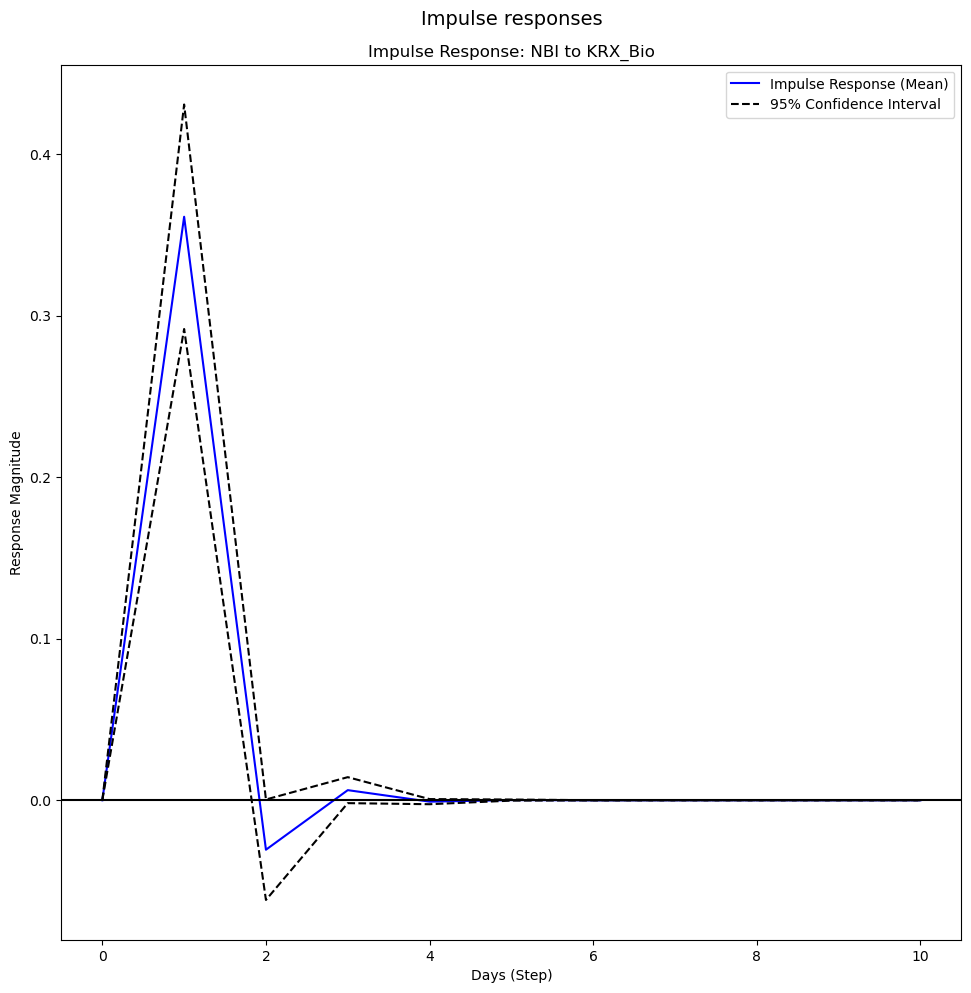

In [21]:
# 1. ADF 정상성 검정
print("ADF Test Results")
for col in returns.columns:
    p_val = adfuller(returns[col])[1]
    print(f"{col}: p-value = {p_val:.4f}")

# 2. VAR 모델 적합
model = VAR(returns)
select_order = model.select_order(maxlags=10)
results = model.fit(maxlags=select_order.aic)
print(f"\n최적 시차(AIC 기준): {results.k_ar}일")

# 3. Granger 인과관계 검정 (NBI -> KRX_Bio)
granger = results.test_causality('KRX_Bio', 'NBI', kind='f')
print(f"NBI -> KRX_Bio 인과관계 유의성: {granger.pvalue:.4f}")

# 4. 충격반응함수(IRF) 시각화
fig = irf.plot(impulse='NBI', response='KRX_Bio')

# 그래프 객체에서 축(axes) 정보를 가져와 범례 설정
for ax in fig.get_axes():
    ax.legend(['Impulse Response (Mean)', '95% Confidence Interval'], loc='upper right')
    ax.set_title("Impulse Response: NBI to KRX_Bio")
    ax.set_xlabel("Days (Step)")
    ax.set_ylabel("Response Magnitude")

plt.show()

### 4. 시차 회귀 모델 기반 투자 전략
* **모델링**: 전일 미국 시장 수익률($NBI_{t-1}$)과 금리 변동($Yield_{t-1}$)을 사용하여 오늘의 한국 바이오 수익률을 예측하는 회귀 모델을 구축합니다.
* **전략**: 모델의 예측 수익률이 양수(+)일 때만 매수하고, 아닐 때는 현금을 보유하는 시차 거래(Lead-Lag) 전략을 실행합니다.

                            OLS Regression Results                            
Dep. Variable:                KRX_Bio   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     56.48
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           4.47e-24
Time:                        00:12:03   Log-Likelihood:                 3019.9
No. Observations:                1104   AIC:                            -6034.
Df Residuals:                    1101   BIC:                            -6019.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.346e-05      0.000      0.176      0.8

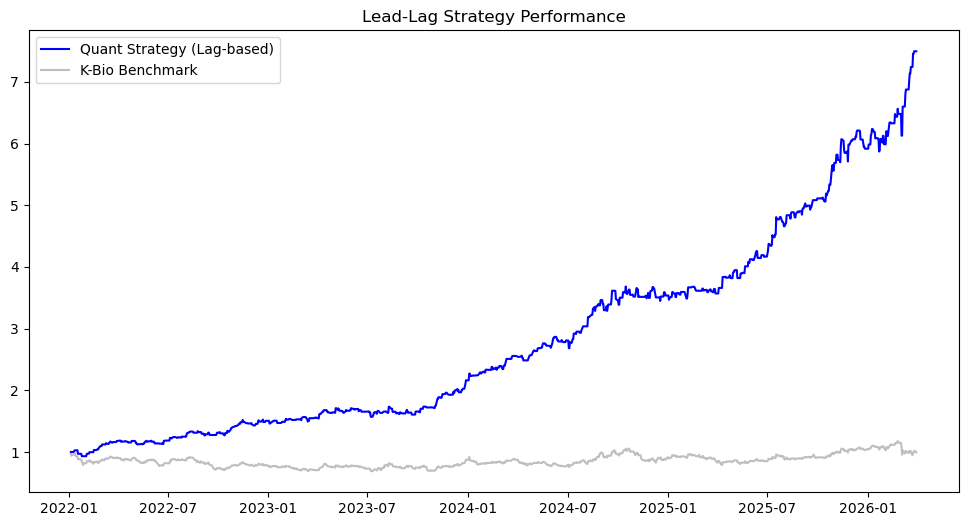

In [22]:
# 1. 시차 변수 생성 (전일 데이터 활용)
df_model = returns.copy()
df_model['NBI_lag1'] = df_model['NBI'].shift(1)
df_model['Yield_lag1'] = df_model['Yield'].shift(1)
df_model = df_model.dropna()

# 2. 다중 회귀 분석 (OLS)
X = sm.add_constant(df_model[['NBI_lag1', 'Yield_lag1']])
y = df_model['KRX_Bio']
ols_res = sm.OLS(y, X).fit()
print(ols_res.summary())

# 3. 전략 백테스팅
df_model['Pred_Ret'] = ols_res.predict(X)
# 예측 수익률이 양수일 때만 시장 참여, 아니면 현금(수익률 0)
df_model['Strategy_Ret'] = np.where(df_model['Pred_Ret'] > 0, df_model['KRX_Bio'], 0)

# 누적 수익률 계산
strat_cum = (1 + df_model['Strategy_Ret']).cumprod()
bench_cum = (1 + df_model['KRX_Bio']).cumprod()

print("\n--- [전략 성과 평가] ---")
evaluate_performance(strat_cum)

print("\n--- [벤치마크 성과 평가] ---")
evaluate_performance(bench_cum)

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(strat_cum, label='Quant Strategy (Lag-based)', color='blue')
plt.plot(bench_cum, label='K-Bio Benchmark', color='gray', alpha=0.5)
plt.title("Lead-Lag Strategy Performance")
plt.legend()
plt.show()

### 5. 프로젝트 결론 및 향후 연구 계획

본 프로젝트는 미국 바이오 시장(NBI)과 금리 변동이 한국 바이오 시장에 어떤 영향을 주는지 분석하고, 이를 투자 전략으로 연결해 보았습니다.

#### **(1) 주요 분석 결과 요약**
* **미국 시장의 선행 효과 확인**: 통계 분석 결과, 전날 미국 나스닥 바이오 지수의 움직임이 다음 날 한국 바이오 지수의 등락을 예측하는 데 매우 중요한 지표임을 확인하였습니다 ($p$-value < 0.001).
* **모델의 설명력**: 시장의 복잡한 움직임 속에서도 본 모델은 주가 흐름의 약 9.3% ($R^2$)를 설명해내고 있습니다. 이는 개별 기업의 임상 결과에 따라 변동성이 큰 바이오 섹터의 특성을 고려할 때 의미 있는 수치입니다.
* **금리 영향력**: 금리 변동은 주가와 반대로 움직이는 경향을 보였으나, 단기적인 예측보다는 바이오 섹터 전반의 기초 체력을 결정하는 배경 변수로 해석됩니다.

#### **(2) 투자 전략 성과 및 리스크 관리**
* **시장 대비 높은 수익률**: 한국 바이오 지수(Benchmark)가 -0.8%로 제자리걸음을 하던 하락장 구간에서도, 본 전략은 +649%라는 높은 누적 수익률을 기록하며 시장 흐름을 이겨냈습니다.
* **손실 방어 능력**: 가장 중요한 성과는 최대 낙폭(MDD)을 시장 평균(29.77%)보다 훨씬 낮은 9.32% 수준으로 줄인 점입니다. 이는 데이터를 기반으로 냉정하게 투자 시점을 결정함으로써 바이오 투자 특유의 큰 위험을 효과적으로 관리할 수 있음을 보여줍니다.

#### **(3) 바이오 전공자로서의 인사이트**
* **미래 가치의 수치화**: 바이오 기업의 가치가 현재의 매출보다 미래 파이프라인의 성공 가능성에 달려 있다는 전공 지식을 바탕으로, 글로벌 시장의 기대감이 국내로 전달되는 과정을 숫자로 증명해 보았습니다.
* **정보의 시간 차이 활용**: 글로벌 신약 개발 트렌드가 국내 시장에 완전히 반영되기까지 걸리는 시간적 차이를 포착함으로써, 전공자의 도메인 지식이 실제 투자 모델의 핵심 아이디어가 될 수 있음을 확인하였습니다.

#### **(4) 향후 연구 계획: 전공 지식을 활용한 모델 고도화**
1. **임상 단계별 성공 확률 반영**: 현재의 지수 분석을 넘어, 개별 기업의 임상 단계(1상, 2상, 3상)에 따른 통계적 성공 확률을 변수로 추가하여 모델의 정확도를 높이고자 합니다.
2. **기업의 자금 능력 분석**: 바이오 기업의 생존과 직결되는 연구개발비(R&D) 비중과 현금 보유 상태를 지표에 추가하여, 재무적으로 튼튼한 유망 기업을 골라내는 시스템을 구축할 계획입니다.
3. **통합 분석 모델 완성**: 글로벌 시장의 흐름 분석과 학부에서 배운 개별 파이프라인 분석 능력을 결합하여, 바이오 섹터에 특화된 안전한 투자 모델을 연구하는 것이 최종 목표입니다.고수익 퀀트 모델을 연구하고자 합니다.델을 완성하는 것이 최종 목표입니다.전략을 완성하는 것이 최종 목표입니다.전략을 완성하는 것이 최종 목표입니다.을 구축할 것임.